# **Healthcare 30-Day Readmission Prediction**

# Objectives
This project analyzes patient-level healthcare data to investigate factors associated with 30-day hospital readmission and evaluate the ability of machine learning models to predict readmission risk.
# key Questions
What patient and discharge characteristics are associated with 30-day readmission?
Does length of hospital stay differ between readmitted and non-readmitted patients?
Which variables contribute most to prediction?
How effectively can machine learning models identify patients at risk of readmission?

### **Project Overview**
This project focuses on analyzing and predicting 30-day hospital readmission using patient-level healthcare data. The analysis explores demographic, clinical, medication, hospitalization, and discharge-related factors that may be associated with whether a patient is readmitted within 30 days of discharge.
The dataset contains 30,000 patient records and 14 variables. Exploratory data analysis was conducted to identify patterns in readmission rates, including the relationship between readmission and length of stay, diabetes, hypertension, and discharge destination. Machine learning models including Logistic Regression, Random Forest, and XGBoost were developed and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.
Because only 12.25% of patients experienced 30-day readmission, class imbalance was specifically addressed during modeling. The results showed that discharge destination had one of the clearest associations with readmission, while the available variables provided limited predictive power for individual readmission risk.

The project demonstrates an end-to-end healthcare data science workflow, from data exploration and preprocessing to machine learning, model evaluation, feature analysis, and interpretation of healthcare insights

In [34]:
import numpy as np

In [35]:
import pandas as pd

df = pd.read_csv('/content/hospital_readmissions_30k.csv')
display(df.head())

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [36]:
missing_data = df.isnull().sum()
display(missing_data[missing_data > 0])

,0


In [37]:
display(df.describe(include='all'))

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
count,30000.000000,30000.000000,30000,30000,30000.000000,30000.000000,30000,30000,30000.000000,30000.000000,30000,30000
unique,NaN,NaN,3,1581,NaN,NaN,2,2,NaN,NaN,3,2
top,NaN,NaN,Male,143/94,NaN,NaN,No,No,NaN,NaN,Home,No
freq,NaN,NaN,10097,41,NaN,NaN,15051,15022,NaN,NaN,20877,26326
mean,15000.500000,53.884233,NaN,NaN,225.260400,28.946263,NaN,NaN,5.012267,5.502900,NaN,NaN
std,8660.398374,21.056485,NaN,NaN,43.585671,6.348204,NaN,NaN,3.166383,2.867298,NaN,NaN
min,1.000000,18.000000,NaN,NaN,150.000000,18.000000,NaN,NaN,0.000000,1.000000,NaN,NaN
25%,7500.750000,36.000000,NaN,NaN,188.000000,23.400000,NaN,NaN,2.000000,3.000000,NaN,NaN
50%,15000.500000,54.000000,NaN,NaN,225.000000,28.900000,NaN,NaN,5.000000,5.000000,NaN,NaN
75%,22500.250000,72.000000,NaN,NaN,263.000000,34.500000,NaN,NaN,8.000000,8.000000,NaN,NaN


In [39]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- gender ---
gender
Male      10097
Other     10024
Female     9879
Name: count, dtype: int64

--- blood_pressure ---
blood_pressure
143/94     41
141/90     33
120/77     33
110/98     33
130/97     33
           ..
117/85      9
126/100     8
115/81      8
113/79      8
149/80      7
Name: count, Length: 1581, dtype: int64

--- diabetes ---
diabetes
No     15051
Yes    14949
Name: count, dtype: int64

--- hypertension ---
hypertension
No     15022
Yes    14978
Name: count, dtype: int64

--- discharge_destination ---
discharge_destination
Home                20877
Rehab                6096
Nursing_Facility     3027
Name: count, dtype: int64

--- readmitted_30_days ---
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64


In [38]:
df.info()
df.shape
df['readmitted_30_days'].value_counts()
df['readmitted_30_days'].value_counts(normalize=True) * 100

print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate patient IDs: {df['patient_id'].duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB
Total duplicate rows: 0
Duplicate patient IDs: 0


In [40]:
df[['systolic_bp', 'diastolic_bp']] = df['blood_pressure'].str.split(
    '/', expand=True
).astype(int)

In [41]:
df[['blood_pressure', 'systolic_bp', 'diastolic_bp']].head()

,blood_pressure,systolic_bp,diastolic_bp
0,130/72,130,72
1,120/92,120,92
2,135/78,135,78
3,123/80,123,80
4,135/84,135,84


In [42]:
df[['blood_pressure', 'systolic_bp', 'diastolic_bp']].head()

,blood_pressure,systolic_bp,diastolic_bp
0,130/72,130,72
1,120/92,120,92
2,135/78,135,78
3,123/80,123,80
4,135/84,135,84


In [43]:
pd.crosstab(
    df['hypertension'],
    df['readmitted_30_days'],
    normalize='index'
) * 100

readmitted_30_days,No,Yes
hypertension,,
No,88.490214,11.509786
Yes,87.014288,12.985712


In [44]:
pd.crosstab(
    df['gender'],
    df['readmitted_30_days'],
    normalize='index'
) * 100
pd.crosstab(
    df['gender'],
    df['readmitted_30_days'],
    normalize='index'
) * 100

readmitted_30_days,No,Yes
gender,,
Female,87.883389,12.116611
Male,87.709221,12.290779
Other,87.669593,12.330407


In [45]:
df.groupby('readmitted_30_days')['length_of_stay'].agg(
    ['count', 'mean', 'median', 'std']
)

,count,mean,median,std
readmitted_30_days,,,,
No,26326,5.510028,6.0,2.865672
Yes,3674,5.451824,5.0,2.878801


In [46]:
los_readmission = (
    df.groupby('length_of_stay')['readmitted_30_days']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='readmission_rate')
)

los_readmission

,length_of_stay,readmission_rate
0,1,12.808219
1,2,13.205678
2,3,11.982928
3,4,11.553918
4,5,12.199143
5,6,12.091503
6,7,11.931244
7,8,12.891156
8,9,12.395029
9,10,11.439842


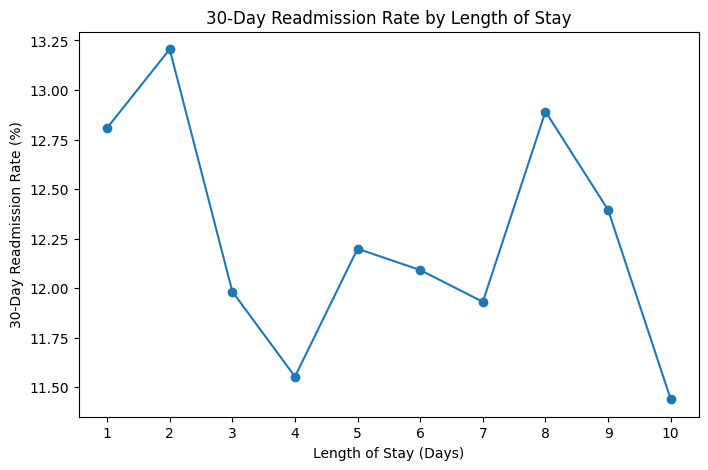

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    los_readmission['length_of_stay'],
    los_readmission['readmission_rate'],
    marker='o'
)

plt.xlabel('Length of Stay (Days)')
plt.ylabel('30-Day Readmission Rate (%)')
plt.title('30-Day Readmission Rate by Length of Stay')
plt.xticks(range(1, 11))
plt.show()


In [48]:
diabetes_readmission = (
    df.groupby('diabetes')['readmitted_30_days']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='readmission_rate')
)

diabetes_readmission
hypertension_readmission = (
    df.groupby('hypertension')['readmitted_30_days']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='readmission_rate')
)

hypertension_readmission
discharge_readmission = (
    df.groupby('discharge_destination')['readmitted_30_days']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='readmission_rate')
      .sort_values('readmission_rate', ascending=False)
)

discharge_readmission

,discharge_destination,readmission_rate
2,Rehab,17.503281
1,Nursing_Facility,16.848365
0,Home,10.044547


In [49]:
df.shape
df.dtypes
df['readmitted_30_days'].value_counts()

,count
readmitted_30_days,
No,26326
Yes,3674


In [50]:
# Check the dataset structure before modeling

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nTarget distribution:")
print(df['readmitted_30_days'].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Shape: (30000, 14)

Data types:
patient_id                 int64
age                        int64
gender                    object
blood_pressure            object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
readmitted_30_days        object
systolic_bp                int64
diastolic_bp               int64
dtype: object

Target distribution:
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64

Missing values:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
systolic_bp              0
diastolic_bp             0
dtyp

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Drop patient ID
X = df.drop(columns=['readmitted_30_days', 'patient_id'])
y = df['readmitted_30_days'].map({'No': 0, 'Yes': 1})

# Identify columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape)
print("Testing set:", X_test.shape)

Categorical columns: ['gender', 'blood_pressure', 'diabetes', 'hypertension', 'discharge_destination']
Numerical columns: ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay', 'systolic_bp', 'diastolic_bp']

Training set: (24000, 12)
Testing set: (6000, 12)


In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [53]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Logistic Regression Results")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
----------------------------------------
Accuracy: 0.5796666666666667
Precision: 0.13154639175257732
Recall: 0.4340136054421769
F1 Score: 0.20189873417721518
ROC-AUC: 0.5285521768061451

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.60      0.71      5265
           1       0.13      0.43      0.20       735

    accuracy                           0.58      6000
   macro avg       0.51      0.52      0.46      6000
weighted avg       0.79      0.58      0.65      6000


Confusion Matrix:
[[3159 2106]
 [ 416  319]]


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [56]:
print("Random Forest Results")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
----------------------------------------
Accuracy: 0.8775
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5619378387632356

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      5265
           1       0.00      0.00      0.00       735

    accuracy                           0.88      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.77      0.88      0.82      6000


Confusion Matrix:
[[5265    0]
 [ 735    0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

In [57]:
import numpy as np

print("Predicted probability summary:")
print(pd.Series(y_prob_rf).describe())

print("\nProbability percentiles:")
print(np.percentile(y_prob_rf, [50, 75, 90, 95, 99]))


Predicted probability summary:
count    6000.000000
mean        0.107885
std         0.062815
min         0.010000
25%         0.060000
50%         0.090000
75%         0.143333
max         0.410000
dtype: float64

Probability percentiles:
[0.09       0.14333333 0.19666667 0.23333333 0.29666667]


In [58]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [59]:
print("XGBoost Results")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Results
----------------------------------------
Accuracy: 0.8775
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.5686148419481754

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      5265
           1       0.00      0.00      0.00       735

    accuracy                           0.88      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.77      0.88      0.82      6000


Confusion Matrix:
[[5265    0]
 [ 735    0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

In [60]:
from xgboost import XGBClassifier

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print("Scale_pos_weight:", scale_pos_weight)

Scale_pos_weight: 7.166042871725076


In [61]:
xgb_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_balanced.fit(X_train, y_train)

y_pred_xgb_balanced = xgb_balanced.predict(X_test)
y_prob_xgb_balanced = xgb_balanced.predict_proba(X_test)[:, 1]

In [62]:
print("Balanced XGBoost Results")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_balanced))
print("Precision:", precision_score(y_test, y_pred_xgb_balanced))
print("Recall:", recall_score(y_test, y_pred_xgb_balanced))
print("F1 Score:", f1_score(y_test, y_pred_xgb_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_balanced))

Balanced XGBoost Results
----------------------------------------
Accuracy: 0.7123333333333334
Precision: 0.17803768680961662
Recall: 0.3727891156462585
F1 Score: 0.24098504837291118
ROC-AUC: 0.5696974630307963

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      5265
           1       0.18      0.37      0.24       735

    accuracy                           0.71      6000
   macro avg       0.54      0.57      0.53      6000
weighted avg       0.81      0.71      0.75      6000


Confusion Matrix:
[[4000 1265]
 [ 461  274]]


In [63]:
# Get the trained preprocessing and XGBoost components
trained_preprocessor = xgb_balanced.named_steps['preprocessor']
trained_xgb = xgb_balanced.named_steps['classifier']

# Get transformed feature names
feature_names = trained_preprocessor.get_feature_names_out()

# Get feature importance
importance = trained_xgb.feature_importances_

feature_importance = (
    pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    })
    .sort_values('importance', ascending=False)
)

feature_importance.head(15)

,feature,importance
1595,cat__discharge_destination_Home,0.022445
1597,cat__discharge_destination_Rehab,0.009371
1594,cat__hypertension_Yes,0.007539
1592,cat__diabetes_Yes,0.007170
1593,cat__hypertension_No,0.007073
1596,cat__discharge_destination_Nursing_Facility,0.006224
1369,cat__blood_pressure_153/95,0.004122
313,cat__blood_pressure_119/93,0.004006
1591,cat__diabetes_No,0.003862
789,cat__blood_pressure_135/73,0.003593


In [64]:
X = df.drop(
    columns=[
        'readmitted_30_days',
        'patient_id',
        'blood_pressure'
    ]
)

y = df['readmitted_30_days'].map({'No': 0, 'Yes': 1})
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

Categorical: ['gender', 'diabetes', 'hypertension', 'discharge_destination']
Numerical: ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay', 'systolic_bp', 'diastolic_bp']


In [65]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_balanced_clean = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_balanced_clean.fit(X_train, y_train)

y_pred_clean = xgb_balanced_clean.predict(X_test)
y_prob_clean = xgb_balanced_clean.predict_proba(X_test)[:, 1]

In [66]:
print("Clean Balanced XGBoost")
print("-" * 40)

print("Accuracy:", accuracy_score(y_test, y_pred_clean))
print("Precision:", precision_score(y_test, y_pred_clean))
print("Recall:", recall_score(y_test, y_pred_clean))
print("F1 Score:", f1_score(y_test, y_pred_clean))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_clean))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_clean))

Clean Balanced XGBoost
----------------------------------------
Accuracy: 0.6821666666666667
Precision: 0.15969802555168408
Recall: 0.3741496598639456
F1 Score: 0.22385022385022385
ROC-AUC: 0.5617606966813317

Confusion Matrix:
[[3818 1447]
 [ 460  275]]


# Project Conclusions

The analysis of 30-day hospital readmission data provided several important findings regarding patient characteristics, discharge outcomes, and the ability to predict readmission.

The exploratory analysis showed that **discharge destination was one of the clearest variables associated with 30-day readmission**. Patients discharged to rehabilitation facilities had a readmission rate of approximately **17.5%**, followed by patients discharged to nursing facilities at **16.85%**, while patients discharged home had a substantially lower rate of **10.04%**. This indicates that discharge destination may reflect differences in patient condition, care requirements, or post-discharge support. However, this relationship should be interpreted as an association rather than evidence that discharge destination itself causes readmission.

In contrast, **length of stay showed little differentiation between readmitted and non-readmitted patients**. The average length of stay was approximately **5.51 days** among patients who were not readmitted and **5.45 days** among those who were readmitted. Readmission rates across individual lengths of stay also remained relatively stable, ranging from approximately **11.4% to 13.2%**. Therefore, length of stay did not appear to be a strong standalone indicator of 30-day readmission in this dataset.

The machine learning analysis demonstrated that **30-day readmission is difficult to predict using the available variables**. Logistic Regression achieved a ROC-AUC of approximately **0.529**, while Random Forest and XGBoost achieved approximately **0.562 and 0.569**, respectively. Although Random Forest and standard XGBoost achieved around **87.75% accuracy**, this result was misleading because the dataset was highly imbalanced: only **12.25% of patients were readmitted**, meaning a model predicting every patient as non-readmitted could achieve approximately 87.75% accuracy.

Applying class weighting to XGBoost improved its ability to identify readmitted patients, increasing recall from **0% to approximately 37.3%**. However, precision remained low at approximately **17.8%**, and ROC-AUC remained around **0.57**. This indicates that addressing class imbalance improved minority-class detection but did not substantially improve the model's overall discriminatory ability.

Feature-importance analysis identified **discharge destination, hypertension, diabetes, and blood-pressure-related variables** among the more influential predictors. However, removing the categorical `blood_pressure` variable and retaining systolic and diastolic blood pressure as numerical variables did not substantially improve model performance. The clean balanced XGBoost model achieved a ROC-AUC of approximately **0.562**.

Overall, the findings suggest that **the variables available in this dataset have limited predictive power for individual 30-day readmission risk**. The project therefore demonstrates an important distinction between identifying variables that are associated with readmission and building a reliable predictive model. While certain patient and discharge characteristics show meaningful differences between groups, these variables alone are insufficient to produce a highly accurate readmission prediction model.

For future work, model performance could potentially be improved by incorporating additional information such as **previous hospital admissions, comorbidities, clinical severity, laboratory results, previous emergency visits, medication changes, follow-up care, and socioeconomic or post-discharge support factors**. More advanced feature engineering, threshold optimization, hyperparameter tuning, and alternative approaches to class imbalance could also be explored.

**In conclusion, this project successfully identified important patterns in hospital readmission data and demonstrated the limitations of predicting 30-day readmission using a relatively small set of patient-level variables. The results provide a useful baseline for future research and demonstrate that healthcare prediction models should be evaluated using multiple metrics rather than accuracy alone.**
